## OPT-1.3B LoRA Evaluation

In [1]:
import json
import random
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

## Load Data & Model

In [2]:
DATA_DIR = Path("../data")

def load_clean(file_path):
    data = []
    with open(file_path, "r") as f:
        for line in f:
            data.append(json.loads(line))
    return data

test_raw = load_clean(DATA_DIR / "clean_dolly_test.json")
print(f"Test examples: {len(test_raw)}")

Test examples: 3003


In [ ]:
model_id = "facebook/opt-1.3b"
tokenizer = AutoTokenizer.from_pretrained(model_id)

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, device_map="cpu", torch_dtype=torch.float16
)
model = PeftModel.from_pretrained(base_model, "../model/opt_model")
model.eval()
print("model loaded")

`torch_dtype` is deprecated! Use `dtype` instead!
d:\miniconda3\envs\ai\Lib\site-packages\huggingface_hub\file_download.py:768: UserWarning: Not enough free disk space to download the file. The expected file size is: 2631.64 MB. The target location C:\Users\YASER\.cache\huggingface\hub\models--facebook--opt-1.3b\blobs only has 2372.22 MB free disk space.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

OSError: Can't load the model for 'facebook/opt-1.3b'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'facebook/opt-1.3b' is the correct path to a directory containing a file named pytorch_model.bin.

In [ ]:
def generate_answer(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    output = tokenizer.decode(out[0], skip_special_tokens=True)
    return output[len(prompt):].strip()

## Balanced Sampling & Inference
Stratified sampling equal examples per category for fair evaluation.

In [ ]:
random.seed(42)

by_category = defaultdict(list)
for i, ex in enumerate(test_raw):
    by_category[ex["category"]].append(i)

k_per_cat = min(len(v) for v in by_category.values())
k_per_cat = min(k_per_cat, 5)

print(f"Sampling {k_per_cat} per category ({len(by_category)} categories)")

sample_indices = []
for cat in sorted(by_category):
    sample_indices.extend(random.sample(by_category[cat], k_per_cat))

print(f"Total balanced sample: {len(sample_indices)}")

preds = []
refs = []
categories = []

for idx in sample_indices:
    ex = test_raw[idx]
    prompt = f"Instruction: {ex['instruction']}\n"
    if ex.get("context"):
        prompt += f"Context: {ex['context']}\n"
    prompt += "Answer:"

    out = generate_answer(prompt)
    preds.append(out)
    refs.append(ex["response"])
    categories.append(ex["category"])
    
print("Done")

Sampling 5 per category (8 categories)
Total balanced sample: 40
Done


## Evaluation: BLEU, ROUGE, BERTScore

In [ ]:
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

b = bleu.compute(predictions=preds, references=[[r] for r in refs])
r = rouge.compute(predictions=preds, references=refs)
bs = bertscore.compute(predictions=preds, references=refs, lang="en")
avg_bert = sum(bs["f1"]) / len(bs["f1"])

print("=== Overall ===")
print(f"BLEU: {b['bleu']:.4f}")
print(f"ROUGE-1: {r['rouge1']:.4f}  ROUGE-2: {r['rouge2']:.4f}  ROUGE-L: {r['rougeL']:.4f}")
print(f"BERTScore F1: {avg_bert:.4f}")

print("\n=== Per-Category ===")
rows = []
for cat in sorted(set(categories)):
    idxs = [i for i, c in enumerate(categories) if c == cat]
    cat_preds = [preds[i] for i in idxs]
    cat_refs = [refs[i] for i in idxs]
    if len(cat_preds) < 2:
        continue
    cb = bleu.compute(predictions=cat_preds, references=[[r] for r in cat_refs])
    cr = rouge.compute(predictions=cat_preds, references=cat_refs)
    cbs = bertscore.compute(predictions=cat_preds, references=cat_refs, lang="en")
    rows.append({
        "Category": cat,
        "Count": len(idxs),
        "BLEU": round(cb["bleu"], 4),
        "ROUGE-L": round(cr["rougeL"], 4),
        "BERTScore": round(sum(cbs["f1"])/len(cbs["f1"]), 4)
    })

print(pd.DataFrame(rows).to_string(index=False))

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


=== Overall ===
BLEU: 0.0632
ROUGE-1: 0.3178  ROUGE-2: 0.1267  ROUGE-L: 0.2529
BERTScore F1: 0.8651

=== Per-Category ===
              Category  Count   BLEU  ROUGE-L  BERTScore
         brainstorming      5 0.0590   0.1897     0.8618
        classification      5 0.1429   0.5707     0.9311
             closed_qa      5 0.0741   0.4094     0.8802
      creative_writing      5 0.0096   0.1479     0.8334
            general_qa      5 0.0224   0.1743     0.8597
information_extraction      5 0.0448   0.1156     0.8247
               open_qa      5 0.0323   0.1236     0.8401
         summarization      5 0.2259   0.3072     0.8900


## Sample Outputs

In [ ]:
for i in range(min(5, len(preds))):
    idx = sample_indices[i]
    ex = test_raw[idx]
    print(f"Example {i+1} [{categories[i]}]")
    print("Instruction:", ex["instruction"])
    print("Reference:", ex["response"])
    print("OPT Output:", preds[i])
    print("=" * 80)

Example 1 [brainstorming]
Instruction: Give me a list of the best sad songs to play.
Reference: ‘Nothing Compares 2 U’ by Sinéad O’Connor
‘Hurt’ by Johnny Cash
‘Only Love Can Break Your Heart’ by Neil Young
‘Teardrop’ by Massive Attack
‘I Know It’s Over’ by The Smiths
‘No Distance Left to Run’ by Blur
‘The Boxer’ by Simon & Garfunkel
‘Tom Traubert’s Blues (Four Sheets to the Wind in Copenhagen)’ by Tom Waits
‘Lazarus’ by David Bowie
llama Output: 1. "Stay" by Adele
2. "Uptown Funk" by Mark Ronson ft. Bruno Mars
3. "Lost in Japan" by Hozier
4. "Lost in You" by Celine Dion
5. "Crazy Love" by George Michael
6. "Dynamite" by BTS
7. "Waterfalls" by TLC
8. "I'm Too Sexy" by Right Said Fred
9. "I Gotta Feeling" by The Black Eyed Peas
10. "The Way I Am" by Alicia Keys
Example 2 [brainstorming]
Instruction: What are four creative ways to use a chess set besides playing chess?
Reference: You could use the pieces to invent a different war game; you could create a bottle flipping game with the kin

### Cross-Model Analysis

| Model | Type | Parameters |
|-------|------|-----------|
| DeepSeek | API (cloud) | ~67B |
| TinyLlama + LoRA | Local fine-tuned (instruction-tuned base) | 1.1B |
| OPT-1.3B + LoRA | Local fine-tuned (base model) | 1.3B |

Comparing two LoRA-adapted models of similar size but different starting points: TinyLlama is already instruction-tuned while OPT is a base language model. This reveals how much the base model's pretraining matters for instruction-following after fine-tuning.

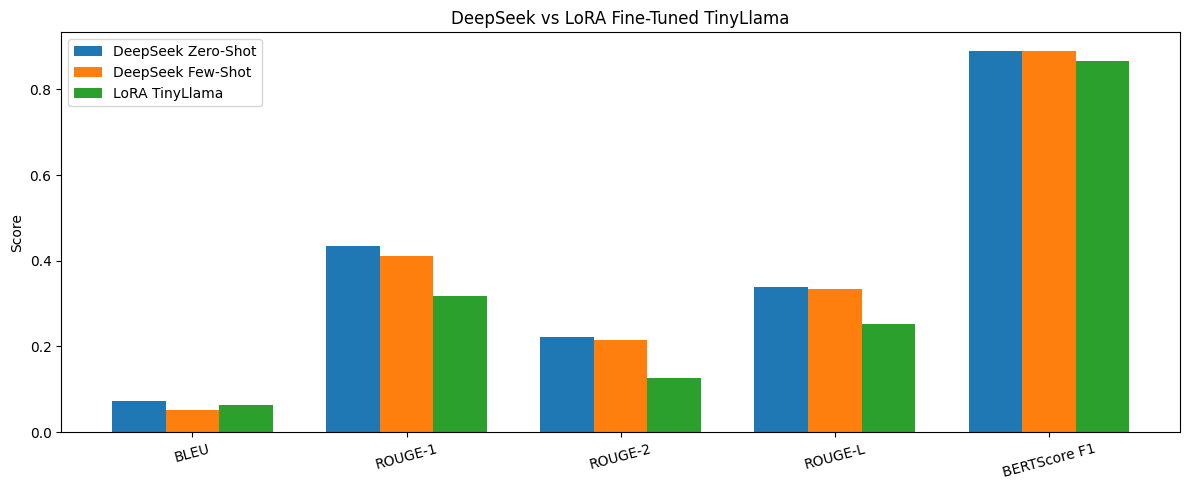

In [ ]:
deep_results = pd.read_csv("zero_vs_few_comparison.csv")

# OPT metrics from current eval
opt_metrics = [b['bleu'], r['rouge1'], r['rouge2'], r['rougeL'], avg_bert]

# Build comparison DataFrame
comparison = pd.DataFrame({
    "Metric": deep_results["Metric"],
    "DeepSeek Zero-Shot": deep_results["Zero-Shot"],
    "DeepSeek Few-Shot": deep_results["Few-Shot"],
    "LoRA OPT-1.3B": opt_metrics
})

metrics = comparison["Metric"].tolist()
x = range(len(metrics))
w = 0.25

plt.figure(figsize=(12, 5))
plt.bar([i - w for i in x], comparison["DeepSeek Zero-Shot"], width=w, label="DeepSeek Zero-Shot")
plt.bar(list(x), comparison["DeepSeek Few-Shot"], width=w, label="DeepSeek Few-Shot")
plt.bar([i + w for i in x], comparison["LoRA OPT-1.3B"], width=w, label="LoRA OPT-1.3B")
plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score")
plt.title("DeepSeek vs LoRA Fine-Tuned OPT-1.3B")
plt.legend()
plt.tight_layout()
plt.show()